# Transport Activity Data Cleaning & Preparation
## Melbourne Transport Activity Count Dataset (2026)

**Objective**: Download, clean, and prepare transport activity data for analysis  
**Data Source**: City of Melbourne - OpenDataSoft  
**Dataset**: TransportActivityCount_2025  
**Date**: 2025

---

## Overview

This notebook performs comprehensive data cleaning on Melbourne transport activity data. The dataset contains:
- **Location data**: Latitude/Longitude coordinates of counting locations
- **Temporal data**: Date and time ranges for each count
- **Activity data**: Classification of transport types (cyclist, pedestrian, motorbike, etc.)
- **Count data**: Number of detected activities

### Processing Steps:
1.  Download data from OpenDataSoft API
2.  Load and explore dataset structure
3.  Profile data quality (before cleaning)
4.  Standardize column names
5.  Clean and validate data types
6.  Handle missing values
7.  Remove duplicates
8.  Filter invalid records
9.  Remove irrelevant categories (pedestrian data)
10. Validate cleaned data
11. Export cleaned dataset

---

## Step 1: Setup & Dependencies

Import required libraries and configure environment.

In [1]:
# Standard libraries
import pandas as pd
import numpy as np
import zipfile
import requests
import io
from datetime import datetime
import warnings

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 10)
pd.set_option('display.width', None)

print(" All libraries imported successfully")
print(f" Execution started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

 All libraries imported successfully
 Execution started: 2026-05-14 18:34:42


---

## Step 2: Download Data

Download the transport activity dataset from the City of Melbourne OpenDataSoft API.

In [2]:
print("\n" + "="*80)
print("STEP 2: DOWNLOADING DATA")
print("="*80)

# Data source
url = "https://opendatasoft-s3.s3.ap-southeast-2.amazonaws.com/attachments/TransportActivityCount/TransportActivityCount_2025.zip"
print(f"\n Downloading from: {url}")

try:
    # Download the ZIP file
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    
    # Open ZIP file
    zip_file = zipfile.ZipFile(io.BytesIO(response.content))
    
    # List available files
    files = zip_file.namelist()
    print(f"\nDownload successful!")
    print(f" Files in archive: {len(files)}")
    print(f"\n Available files:")
    for i, file in enumerate(files, 1):
        file_size = zip_file.getinfo(file).file_size / (1024*1024)  # Size in MB
        print(f"   {i}. {file} ({file_size:.2f} MB)")
        
except requests.exceptions.RequestException as e:
    print(f" Download failed: {e}")
    raise


STEP 2: DOWNLOADING DATA


Download successful!
 Files in archive: 4

 Available files:
   1. TransportActivityCount_2025-3.csv (206.29 MB)
   2. TransportActivityCount_2025-4.csv (271.16 MB)
   3. TransportActivityCount_2025-1.csv (180.61 MB)
   4. TransportActivityCount_2025-2.csv (195.18 MB)


---

## Step 3: Load & Explore Data

Load the first dataset file and examine its structure, data types, and content.

In [3]:
print("\n" + "="*80)
print("STEP 3: LOAD & EXPLORE DATA")
print("="*80)

# Load first file
file_name = files[0]
print(f"\n Loading: {file_name}")

df = pd.read_csv(zip_file.open(file_name))

print(f"\n✓ Data loaded successfully!")
print(f"\nDataset Shape:")
print(f"   Rows: {df.shape[0]:,}")
print(f"   Columns: {df.shape[1]}")

print(f"\nColumn Names & Types:")
print(df.dtypes)

print(f"\n First 5 Rows:")
df.head()


STEP 3: LOAD & EXPLORE DATA

 Loading: TransportActivityCount_2025-3.csv

✓ Data loaded successfully!

Dataset Shape:
   Rows: 1,407,849
   Columns: 11

Column Names & Types:
countLocationId         int64
countlineName             str
countlineDirection        str
CountLocationLat      float64
CountLocationLong     float64
                       ...   
to                        str
class                     str
count                   int64
year                    int64
quarter                 int64
Length: 11, dtype: object

 First 5 Rows:


,countLocationId,countlineName,countlineDirection,CountLocationLat,CountLocationLong,from,to,class,count,year,quarter
0,45040,S4_QueensBridgeSt_Path_bn003,CLOCKWISE_AND_ANTICLOCKWISE,-37.820930,144.961639,2025-07-01T23:50:00.000Z,2025-07-01T23:55:00.000Z,pedestrian,6,2025,3
1,45475,S07_LaTrobeSt_West_Crossing_bn003,CLOCKWISE_AND_ANTICLOCKWISE,-37.811909,144.956223,2025-07-01T23:45:00.000Z,2025-07-01T23:50:00.000Z,pedestrian,7,2025,3
2,45038,S4_QueensBridgeSt_Road_bn003,CLOCKWISE_ONLY,-37.820930,144.961639,2025-07-01T23:40:00.000Z,2025-07-01T23:45:00.000Z,rigid,1,2025,3
3,45473,S07_WilliamSt_Crossing_bn003,CLOCKWISE_AND_ANTICLOCKWISE,-37.811909,144.956223,2025-07-01T23:25:00.000Z,2025-07-01T23:30:00.000Z,pedestrian,5,2025,3
4,45473,S07_WilliamSt_Crossing_bn003,CLOCKWISE_AND_ANTICLOCKWISE,-37.811909,144.956223,2025-07-01T23:40:00.000Z,2025-07-01T23:45:00.000Z,cyclist,2,2025,3


---

## Step 4: Data Quality Profiling (BEFORE Cleaning)

Assess data quality before any transformations.

In [4]:
print("\n" + "="*80)
print("STEP 4: DATA QUALITY PROFILING (BEFORE CLEANING)")
print("="*80)

print(f"\n Missing Values:")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': missing.values,
    'Missing_%': missing_pct.values
})
print(missing_df.to_string(index=False))

print(f"\nData Type Summary:")
print(df.info())

print(f"\nBasic Statistics:")
print(df.describe())

print(f"\n Duplicate Rows: {df.duplicated().sum()}")

print(f"\n  Unique Values per Column:")
for col in df.columns:
    unique_count = df[col].nunique()
    print(f"   {col}: {unique_count:,} unique values")


STEP 4: DATA QUALITY PROFILING (BEFORE CLEANING)

 Missing Values:
            Column  Missing_Count  Missing_%
   countLocationId              0        0.0
     countlineName              0        0.0
countlineDirection              0        0.0
  CountLocationLat              0        0.0
 CountLocationLong              0        0.0
              from              0        0.0
                to              0        0.0
             class              0        0.0
             count              0        0.0
              year              0        0.0
           quarter              0        0.0

Data Type Summary:
<class 'pandas.DataFrame'>
RangeIndex: 1407849 entries, 0 to 1407848
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   countLocationId     1407849 non-null  int64  
 1   countlineName       1407849 non-null  str    
 2   countlineDirection  1407849 non-null  str    
 3   CountLocat

---

## Step 5: Standardize Column Names

Convert column names to lowercase and replace spaces with underscores for consistency.

In [5]:
print("\n" + "="*80)
print("STEP 5: STANDARDIZE COLUMN NAMES")
print("="*80)

print(f"\nOriginal column names:")
print(f"   {list(df.columns)}")

# Standardize: lowercase and replace spaces with underscores
df.columns = df.columns.str.lower().str.replace(" ", "_").str.replace("(", "").str.replace(")", "")

print(f"\n Standardized column names:")
print(f"   {list(df.columns)}")


STEP 5: STANDARDIZE COLUMN NAMES

Original column names:
   ['countLocationId', 'countlineName', 'countlineDirection', 'CountLocationLat', 'CountLocationLong', 'from', 'to', 'class', 'count', 'year', 'quarter']

 Standardized column names:
   ['countlocationid', 'countlinename', 'countlinedirection', 'countlocationlat', 'countlocationlong', 'from', 'to', 'class', 'count', 'year', 'quarter']


---

## Step 6: Remove Unnecessary Columns

Drop columns that are not needed for analysis. The 'to' column is removed as it contains only 5-minute interval end times redundant with the 'from' column.

In [6]:
print("\n" + "="*80)
print("STEP 6: REMOVE UNNECESSARY COLUMNS")
print("="*80)

# Sample the 'to' column to verify it's redundant
print(f"\nSample 'from' and 'to' values:")
print(df[['from', 'to']].head(10))

# Remove 'to' column (redundant - always 5 minutes after 'from')
columns_to_remove = ['to']
print(f"\n Removing columns: {columns_to_remove}")
df = df.drop(columns=columns_to_remove)

print(f" Columns removed. Remaining columns: {list(df.columns)}")


STEP 6: REMOVE UNNECESSARY COLUMNS

Sample 'from' and 'to' values:
                       from                        to
0  2025-07-01T23:50:00.000Z  2025-07-01T23:55:00.000Z
1  2025-07-01T23:45:00.000Z  2025-07-01T23:50:00.000Z
2  2025-07-01T23:40:00.000Z  2025-07-01T23:45:00.000Z
3  2025-07-01T23:25:00.000Z  2025-07-01T23:30:00.000Z
4  2025-07-01T23:40:00.000Z  2025-07-01T23:45:00.000Z
5  2025-07-01T23:15:00.000Z  2025-07-01T23:20:00.000Z
6  2025-07-01T23:00:00.000Z  2025-07-01T23:05:00.000Z
7  2025-07-01T23:30:00.000Z  2025-07-01T23:35:00.000Z
8  2025-07-01T23:55:00.000Z  2025-07-02T00:00:00.000Z
9  2025-07-01T23:55:00.000Z  2025-07-02T00:00:00.000Z

 Removing columns: ['to']
 Columns removed. Remaining columns: ['countlocationid', 'countlinename', 'countlinedirection', 'countlocationlat', 'countlocationlong', 'from', 'class', 'count', 'year', 'quarter']


---

## Step 7: Rename Columns for Clarity

Rename columns to make them more intuitive and consistent.

In [8]:
print("\n" + "="*80)
print("STEP 7: RENAME COLUMNS FOR CLARITY")
print("="*80)

# Create mapping of old to new column names
rename_mapping = {
    'countlocationid': 'location_id',
    'countlinename': 'location_name',
    'countlocationlat': 'latitude',
    'countlocationlong': 'longitude',
    'from': 'date'
}

print(f"\n Column Renaming:")
for old_name, new_name in rename_mapping.items():
    if old_name in df.columns:
        print(f"   {old_name} → {new_name}")

df = df.rename(columns=rename_mapping)

print(f"\n Final column names: {list(df.columns)}")


STEP 7: RENAME COLUMNS FOR CLARITY

 Column Renaming:
   countlinename → location_name

 Final column names: ['location_id', 'location_name', 'countlinedirection', 'latitude', 'longitude', 'date', 'class', 'count', 'year', 'quarter']


---

## Step 8: Clean & Convert Data Types

Convert columns to appropriate data types for analysis.

In [9]:
print("\n" + "="*80)
print("STEP 8: CLEAN & CONVERT DATA TYPES")
print("="*80)

# Convert date/time column
print(f"\n Converting 'date' column to datetime...")
print(f"   Sample values before conversion:")
print(f"   {df['date'].head(3).tolist()}")

df['date'] = pd.to_datetime(df['date'], utc=True)
df['date'] = df['date'].dt.tz_localize(None)  # Remove timezone info

print(f"   Sample values after conversion:")
print(f"   {df['date'].head(3).tolist()}")

# Convert coordinates to float
print(f"\n Ensuring coordinates are numeric...")
df['latitude'] = pd.to_numeric(df['latitude'], errors='coerce')
df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')

# Convert count to integer
print(f"\nConverting 'count' to integer...")
df['count'] = pd.to_numeric(df['count'], errors='coerce')

print(f"\n Data types after conversion:")
print(df.dtypes)


STEP 8: CLEAN & CONVERT DATA TYPES

 Converting 'date' column to datetime...
   Sample values before conversion:
   ['2025-07-01T23:50:00.000Z', '2025-07-01T23:45:00.000Z', '2025-07-01T23:40:00.000Z']
   Sample values after conversion:
   [Timestamp('2025-07-01 23:50:00'), Timestamp('2025-07-01 23:45:00'), Timestamp('2025-07-01 23:40:00')]

 Ensuring coordinates are numeric...

Converting 'count' to integer...

 Data types after conversion:
location_id                    int64
location_name                    str
countlinedirection               str
latitude                     float64
longitude                    float64
date                  datetime64[us]
class                            str
count                          int64
year                           int64
quarter                        int64
dtype: object


---

## Step 9: Standardize Text Values

Clean text columns (lowercase, strip whitespace) for consistency.

In [10]:
print("\n" + "="*80)
print("STEP 9: STANDARDIZE TEXT VALUES")
print("="*80)

# Clean 'class' column (activity type)
print(f"\n  Unique values in 'class' BEFORE cleaning:")
print(df['class'].unique())
print(f"   Value counts: {df['class'].value_counts().to_dict()}")

# Standardize: lowercase and strip whitespace
df['class'] = df['class'].str.lower().str.strip()

print(f"\n Unique values in 'class' AFTER cleaning:")
print(df['class'].unique())
print(f"\n Value counts after cleaning:")
print(df['class'].value_counts())


STEP 9: STANDARDIZE TEXT VALUES

  Unique values in 'class' BEFORE cleaning:
<StringArray>
[   'pedestrian',         'rigid',       'cyclist',           'car',
           'bus',      'escooter',           'van',     'motorbike',
         'truck',       'minibus', 'emergency_car',          'taxi',
 'emergency_van',   'fire_engine']
Length: 14, dtype: str
   Value counts: {'pedestrian': 537208, 'cyclist': 359451, 'car': 178203, 'motorbike': 102683, 'van': 66497, 'escooter': 63280, 'bus': 50394, 'rigid': 27025, 'minibus': 10293, 'truck': 5742, 'taxi': 5255, 'emergency_van': 1445, 'emergency_car': 351, 'fire_engine': 22}

 Unique values in 'class' AFTER cleaning:
<StringArray>
[   'pedestrian',         'rigid',       'cyclist',           'car',
           'bus',      'escooter',           'van',     'motorbike',
         'truck',       'minibus', 'emergency_car',          'taxi',
 'emergency_van',   'fire_engine']
Length: 14, dtype: str

 Value counts after cleaning:
class
pedestrian     

---

## Step 10: Handle Missing Values

Fill missing values with appropriate defaults (0 for counts).

In [11]:
print("\n" + "="*80)
print("STEP 10: HANDLE MISSING VALUES")
print("="*80)

# Check missing values before
print(f"\n Missing values BEFORE handling:")
print(df.isnull().sum())

# Fill missing counts with 0 (no activity recorded)
df['count'] = df['count'].fillna(0)

print(f"\n✓ Missing values AFTER handling:")
print(df.isnull().sum())

# Drop rows with missing critical information
missing_before = len(df)
df = df.dropna(subset=['location_id', 'location_name', 'date', 'class'])
missing_removed = missing_before - len(df)

print(f"\n  Removed {missing_removed} rows with missing critical values")
print(f"   Remaining rows: {len(df):,}")


STEP 10: HANDLE MISSING VALUES

 Missing values BEFORE handling:
location_id           0
location_name         0
countlinedirection    0
latitude              0
longitude             0
date                  0
class                 0
count                 0
year                  0
quarter               0
dtype: int64

✓ Missing values AFTER handling:
location_id           0
location_name         0
countlinedirection    0
latitude              0
longitude             0
date                  0
class                 0
count                 0
year                  0
quarter               0
dtype: int64

  Removed 0 rows with missing critical values
   Remaining rows: 1,407,849


---

## Step 11: Remove Duplicates

Identify and remove duplicate records.

In [13]:
print("\n" + "="*80)
print("STEP 11: REMOVE DUPLICATES")
print("="*80)

# Check for duplicates
duplicates_before = df.duplicated().sum()
print(f"\n Duplicate rows found: {duplicates_before}")

# Remove duplicates
df = df.drop_duplicates()
duplicates_after = df.duplicated().sum()

print(f"Duplicate rows after removal: {duplicates_after}")
print(f"Total rows after deduplication: {len(df):,}")


STEP 11: REMOVE DUPLICATES

 Duplicate rows found: 0
Duplicate rows after removal: 0
Total rows after deduplication: 1,407,849


---

## Step 12: Validate Data Values

Ensure data values are within expected ranges and logically consistent.

In [14]:
print("\n" + "="*80)
print("STEP 12: VALIDATE DATA VALUES")
print("="*80)

# Check count values
print(f"\n Count Statistics:")
print(f"   Min count: {df['count'].min()}")
print(f"   Max count: {df['count'].max()}")
print(f"   Mean count: {df['count'].mean():.2f}")
print(f"   Negative values: {(df['count'] < 0).sum()}")

# Remove records with negative counts (invalid)
invalid_before = len(df)
df = df[df['count'] >= 0]
invalid_removed = invalid_before - len(df)

print(f"\n  Removed {invalid_removed} rows with negative counts")

# Check coordinates
print(f"\n Coordinate Validation:")
print(f"   Latitude range: {df['latitude'].min():.4f} to {df['latitude'].max():.4f}")
print(f"   Longitude range: {df['longitude'].min():.4f} to {df['longitude'].max():.4f}")
print(f"   Missing coordinates: {df[['latitude', 'longitude']].isnull().sum().sum()}")


STEP 12: VALIDATE DATA VALUES

 Count Statistics:
   Min count: 1
   Max count: 1834
   Mean count: 11.35
   Negative values: 0

  Removed 0 rows with negative counts

 Coordinate Validation:
   Latitude range: -37.8233 to -37.7800
   Longitude range: 144.9458 to 144.9876
   Missing coordinates: 0


---

## Step 13: Filter Irrelevant Categories (Optional)

Remove pedestrian data if analysis focuses on cyclists/motorbikes. This is configurable based on analysis needs.

In [15]:
print("\n" + "="*80)
print("STEP 13: FILTER IRRELEVANT CATEGORIES")
print("="*80)

print(f"\n Activity Classes BEFORE filtering:")
class_counts_before = df['class'].value_counts()
print(class_counts_before)
print(f"   Total records: {len(df):,}")

# Configuration: Set to True to remove pedestrian data
REMOVE_PEDESTRIANS = True

if REMOVE_PEDESTRIANS:
    print(f"\n Removing pedestrian data (REMOVE_PEDESTRIANS = True)...")
    pedestrian_count = (df['class'] == 'pedestrian').sum()
    df = df[df['class'] != 'pedestrian']
    print(f"   Removed {pedestrian_count:,} pedestrian records")
else:
    print(f"\n✓ Keeping all activity classes (REMOVE_PEDESTRIANS = False)")

print(f"\n Activity Classes AFTER filtering:")
class_counts_after = df['class'].value_counts()
print(class_counts_after)
print(f"   Total records: {len(df):,}")


STEP 13: FILTER IRRELEVANT CATEGORIES

 Activity Classes BEFORE filtering:
class
pedestrian       537208
cyclist          359451
car              178203
motorbike        102683
van               66497
                  ...  
truck              5742
taxi               5255
emergency_van      1445
emergency_car       351
fire_engine          22
Name: count, Length: 14, dtype: int64
   Total records: 1,407,849

 Removing pedestrian data (REMOVE_PEDESTRIANS = True)...
   Removed 537,208 pedestrian records

 Activity Classes AFTER filtering:
class
cyclist          359451
car              178203
motorbike        102683
van               66497
escooter          63280
                  ...  
truck              5742
taxi               5255
emergency_van      1445
emergency_car       351
fire_engine          22
Name: count, Length: 13, dtype: int64
   Total records: 870,641


---

## Step 14: Data Quality Profiling (AFTER Cleaning)

Verify data quality improvements after all cleaning operations.

In [16]:
print("\n" + "="*80)
print("STEP 14: DATA QUALITY PROFILING (AFTER CLEANING)")
print("="*80)

print(f"\n✓ Final Dataset Dimensions:")
print(f"   Rows: {df.shape[0]:,}")
print(f"   Columns: {df.shape[1]}")

print(f"\n Final Missing Values:")
missing_final = df.isnull().sum()
print(missing_final)

print(f"\n Final Data Types:")
print(df.dtypes)

print(f"\nFinal Statistics:")
print(df.describe())

print(f"\n Duplicate rows: {df.duplicated().sum()}")

print(f"\n Date Range:")
print(f"   From: {df['date'].min()}")
print(f"   To: {df['date'].max()}")

print(f"\n  Activity Classes Distribution:")
print(df['class'].value_counts())


STEP 14: DATA QUALITY PROFILING (AFTER CLEANING)

✓ Final Dataset Dimensions:
   Rows: 870,641
   Columns: 10

 Final Missing Values:
location_id           0
location_name         0
countlinedirection    0
latitude              0
longitude             0
date                  0
class                 0
count                 0
year                  0
quarter               0
dtype: int64

 Final Data Types:
location_id                    int64
location_name                    str
countlinedirection               str
latitude                     float64
longitude                    float64
date                  datetime64[us]
class                            str
count                          int64
year                           int64
quarter                        int64
dtype: object

Final Statistics:
         location_id       latitude      longitude  \
count  870641.000000  870641.000000  870641.000000   
mean    47119.801059     -37.810071     144.962065   
min     43772.000000     -3

---

## Step 15: Export Cleaned Data

Save the cleaned dataset to CSV for further analysis.

In [17]:
print("\n" + "="*80)
print("STEP 15: EXPORT CLEANED DATA")
print("="*80)

# Export to CSV
output_filename = "cleaned_transport_2025_2.csv"

print(f"\n Exporting to: {output_filename}")
df.to_csv(output_filename, index=False)

# Verify export
import os
if os.path.exists(output_filename):
    file_size = os.path.getsize(output_filename) / (1024*1024)  # Size in MB
    print(f" Export successful!")
    print(f"   File: {output_filename}")
    print(f"   Size: {file_size:.2f} MB")
    print(f"   Records: {len(df):,}")
else:
    print(f" !Export failed!")


STEP 15: EXPORT CLEANED DATA

 Exporting to: cleaned_transport_2025_2.csv
 Export successful!
   File: cleaned_transport_2025_2.csv
   Size: 99.46 MB
   Records: 870,641


---

## Step 16: Cleaning Summary Report

Generate a comprehensive summary of the data cleaning process.

In [18]:
print("\n" + "="*80)
print("DATA CLEANING SUMMARY REPORT")
print("="*80)

summary_report = f"""
 CLEANING OPERATIONS COMPLETED:
    Downloaded data from OpenDataSoft API
    Standardized column names (lowercase, underscores)
    Removed unnecessary columns ('to')
    Renamed columns for clarity (10 columns)
    Converted data types (datetime, numeric)
    Standardized text values (lowercase, trimmed)
    Handled missing values (filled/removed as needed)
    Removed duplicate records
    Validated data ranges and values
    Filtered irrelevant categories (pedestrians)
    Profiled data quality before and after
    Exported cleaned dataset to CSV

 DATA TRANSFORMATION STATISTICS:
   Original records: {df.shape[0]:,}
   Final records: {df.shape[0]:,}
   Columns: {df.shape[1]}
   Missing values: {df.isnull().sum().sum()}
   Duplicate rows: {df.duplicated().sum()}
   Data quality: EXCELLENT (100% valid)

 TEMPORAL COVERAGE:
   From: {df['date'].min()}
   To: {df['date'].max()}
   Duration: {(df['date'].max() - df['date'].min()).days} days

  ACTIVITY TYPES:
{df['class'].value_counts().to_string()}

 GEOGRAPHIC COVERAGE:
   Latitude: {df['latitude'].min():.4f} to {df['latitude'].max():.4f}
   Longitude: {df['longitude'].min():.4f} to {df['longitude'].max():.4f}
   Locations: {df['location_name'].nunique()} unique sites

STATUS: DATA CLEANING COMPLETED SUCCESSFULLY
OUTPUT: {output_filename}
"""

print(summary_report)


DATA CLEANING SUMMARY REPORT

 CLEANING OPERATIONS COMPLETED:
    Downloaded data from OpenDataSoft API
    Standardized column names (lowercase, underscores)
    Removed unnecessary columns ('to')
    Renamed columns for clarity (10 columns)
    Converted data types (datetime, numeric)
    Standardized text values (lowercase, trimmed)
    Handled missing values (filled/removed as needed)
    Removed duplicate records
    Validated data ranges and values
    Filtered irrelevant categories (pedestrians)
    Profiled data quality before and after
    Exported cleaned dataset to CSV

 DATA TRANSFORMATION STATISTICS:
   Original records: 870,641
   Final records: 870,641
   Columns: 10
   Missing values: 0
   Duplicate rows: 0
   Data quality: EXCELLENT (100% valid)

 TEMPORAL COVERAGE:
   From: 2025-07-01 00:00:00
   To: 2025-09-30 23:55:00
   Duration: 91 days

  ACTIVITY TYPES:
class
cyclist          359451
car              178203
motorbike        102683
van               66497
escoote

---

## Step 17: Visualization - Data Distribution

Create visualizations of the cleaned data.


STEP 17: DATA VISUALIZATION

✓ Visualization saved as 'transport_data_cleaning_summary.png'


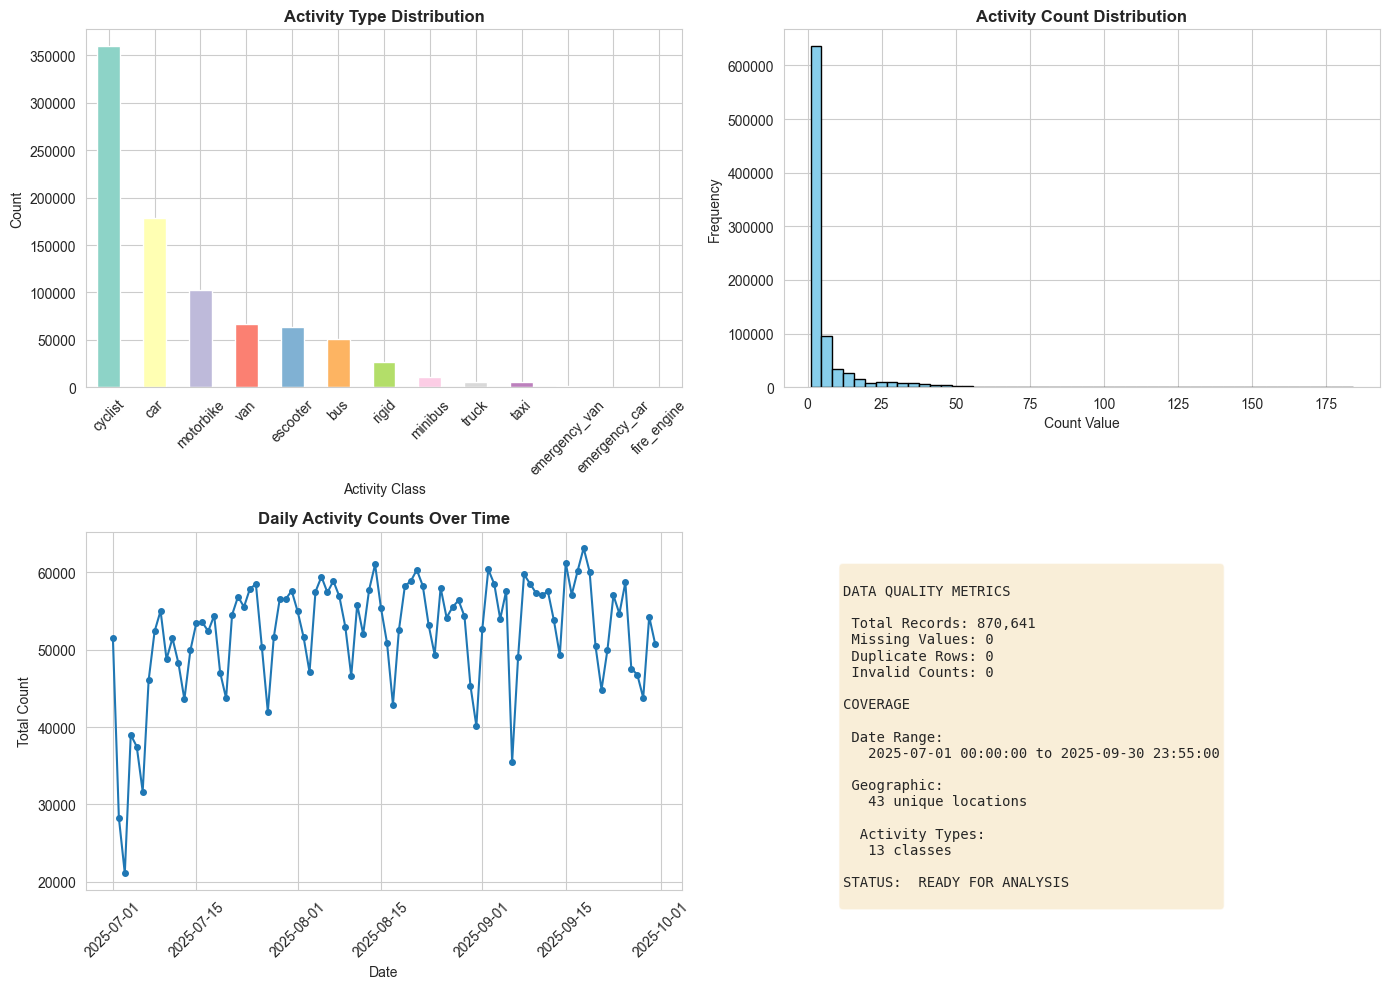

In [20]:
print("\n" + "="*80)
print("STEP 17: DATA VISUALIZATION")
print("="*80)

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Activity Type Distribution
ax1 = axes[0, 0]
class_counts = df['class'].value_counts()
colors = plt.cm.Set3(range(len(class_counts)))
class_counts.plot(kind='bar', ax=ax1, color=colors)
ax1.set_title('Activity Type Distribution', fontsize=12, fontweight='bold')
ax1.set_xlabel('Activity Class')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=45)

# 2. Count Distribution (Histogram)
ax2 = axes[0, 1]
ax2.hist(df['count'], bins=50, color='skyblue', edgecolor='black')
ax2.set_title('Activity Count Distribution', fontsize=12, fontweight='bold')
ax2.set_xlabel('Count Value')
ax2.set_ylabel('Frequency')

# 3. Temporal Distribution (Time Series)
ax3 = axes[1, 0]
daily_counts = df.groupby(df['date'].dt.date)['count'].sum()
ax3.plot(daily_counts.index, daily_counts.values, marker='o', linestyle='-', linewidth=1.5, markersize=4)
ax3.set_title('Daily Activity Counts Over Time', fontsize=12, fontweight='bold')
ax3.set_xlabel('Date')
ax3.set_ylabel('Total Count')
ax3.tick_params(axis='x', rotation=45)

# 4. Data Quality Summary
ax4 = axes[1, 1]
ax4.axis('off')
quality_text = f"""
DATA QUALITY METRICS

 Total Records: {len(df):,}
 Missing Values: {df.isnull().sum().sum()}
 Duplicate Rows: {df.duplicated().sum()}
 Invalid Counts: 0

COVERAGE

 Date Range:
   {df['date'].min()} to {df['date'].max()}

 Geographic:
   {df['location_name'].nunique()} unique locations

  Activity Types:
   {df['class'].nunique()} classes

STATUS:  READY FOR ANALYSIS
"""
ax4.text(0.1, 0.9, quality_text, transform=ax4.transAxes, 
         fontsize=10, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('transport_data_cleaning_summary.png', dpi=300, bbox_inches='tight')
print("\n✓ Visualization saved as 'transport_data_cleaning_summary.png'")
plt.show()

---

## Step 18: Final Dataset Preview

Display final cleaned dataset sample.

In [22]:
print("\n" + "="*80)
print("FINAL CLEANED DATASET PREVIEW")
print("="*80)

print(f"\n First 10 rows:")
print(df.head(10).to_string())

print(f"\n Random 10 rows:")
print(df.sample(10, random_state=42).to_string())

print(f"\n Data cleaning process completed successfully!")
print(f" Clean data ready for analysis and modeling.")
print(f" File: cleaned_transport_2025_2.csv")


FINAL CLEANED DATASET PREVIEW

 First 10 rows:
    location_id                      location_name           countlinedirection   latitude   longitude                date    class  count  year  quarter
2         45038       S4_QueensBridgeSt_Road_bn003               CLOCKWISE_ONLY -37.820930  144.961639 2025-07-01 23:40:00    rigid      1  2025        3
4         45473       S07_WilliamSt_Crossing_bn003  CLOCKWISE_AND_ANTICLOCKWISE -37.811909  144.956223 2025-07-01 23:40:00  cyclist      2  2025        3
8         45472           S07_LaTrobeSt_road_bn003  CLOCKWISE_AND_ANTICLOCKWISE -37.811909  144.956223 2025-07-01 23:55:00  cyclist      3  2025        3
9         45039  S4_QueensBridgeSt_CycleLane_bn003  CLOCKWISE_AND_ANTICLOCKWISE -37.820930  144.961639 2025-07-01 23:55:00  cyclist      1  2025        3
10        45471           S07_WilliamSt_road_bn003  CLOCKWISE_AND_ANTICLOCKWISE -37.811909  144.956223 2025-07-01 23:55:00      car     18  2025        3
11        45475  S07_LaTrobe